In [2]:
# Cell 1: Imports and Load Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from pypfopt import EfficientFrontier, risk_models, expected_returns
from pypfopt import plotting
import scipy.optimize as sco

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 7)

# Load closing prices
close_prices = pd.read_csv('../data/processed/close_prices.csv',
                            index_col='Date', parse_dates=True)

# Load Task 4 inputs (TSLA forecasted return)
task4_inputs = pd.read_csv('../data/processed/task4_inputs.csv',
                            header=None, index_col=0)
tsla_forecast_return = float(task4_inputs.loc['tsla_annualized_forecast_return'].iloc[0])

print("Data loaded successfully!")
print(f"\nAssets: {list(close_prices.columns)}")
print(f"Date range: {close_prices.index[0].date()} to {close_prices.index[-1].date()}")
print(f"TSLA Annualized Forecast Return: {tsla_forecast_return:.4%}")

Data loaded successfully!

Assets: ['BND', 'SPY', 'TSLA']
Date range: 2015-01-02 to 2026-06-29
TSLA Annualized Forecast Return: 0.9511%


=== EXPECTED RETURNS ===

Expected Annual Returns:
  BND: 1.8715%
  SPY: 13.7310%
  TSLA: 0.9511%

(TSLA uses LSTM forecast; BND and SPY use historical averages)

=== COVARIANCE MATRIX ===
           BND       SPY      TSLA
BND   0.002823  0.001085  0.001803
SPY   0.001085  0.031169  0.049820
TSLA  0.001803  0.049820  0.326926


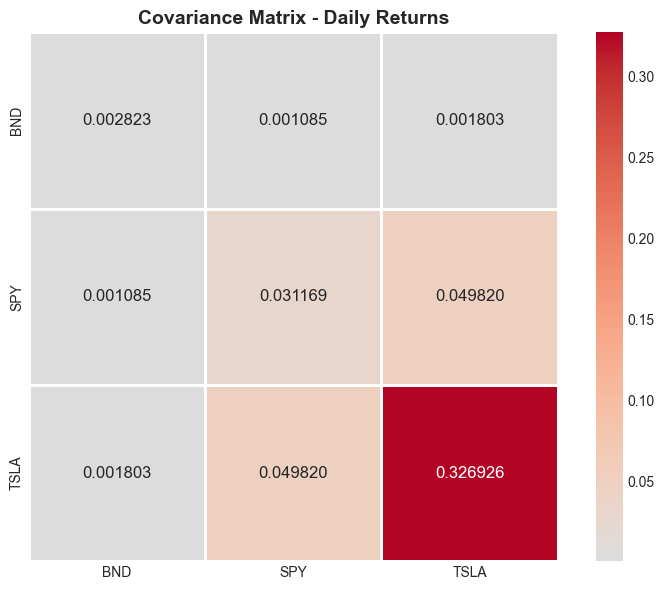

Covariance matrix saved!


In [3]:

print("=== EXPECTED RETURNS ===\n")

# Calculate historical daily returns
daily_returns = close_prices.pct_change().dropna()

# Historical annualized returns for BND and SPY
hist_returns = expected_returns.mean_historical_return(close_prices)

# Override TSLA with LSTM forecasted return
mu = hist_returns.copy()
mu['TSLA'] = tsla_forecast_return

print("Expected Annual Returns:")
for ticker, ret in mu.items():
    print(f"  {ticker}: {ret:.4%}")

print("\n(TSLA uses LSTM forecast; BND and SPY use historical averages)")

# Covariance matrix from historical returns
S = risk_models.sample_cov(close_prices)

print("\n=== COVARIANCE MATRIX ===")
print(S.round(6))

# Plot covariance heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(S, annot=True, fmt='.6f', cmap='coolwarm',
            center=0, square=True, linewidths=1,
            annot_kws={'size': 12})
plt.title('Covariance Matrix - Daily Returns', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/covariance_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Covariance matrix saved!")

In [4]:

print("Generating Efficient Frontier...")

# Run 10,000 random portfolio simulations
n_portfolios = 10000
results = np.zeros((3, n_portfolios))
weights_record = []

for i in range(n_portfolios):
    # Random weights
    w = np.random.random(3)
    w = w / w.sum()
    weights_record.append(w)

    # Portfolio return
    port_return = np.dot(w, mu.values)

    # Portfolio volatility
    port_vol = np.sqrt(np.dot(w.T, np.dot(S.values, w)))

    # Sharpe ratio (risk-free = 2%)
    sharpe = (port_return - 0.02) / port_vol

    results[0, i] = port_vol
    results[1, i] = port_return
    results[2, i] = sharpe

results_df = pd.DataFrame(results.T, columns=['Volatility', 'Return', 'Sharpe'])

print(f"Simulated {n_portfolios:,} random portfolios")
print(f"Return range:     {results_df['Return'].min():.4%} to {results_df['Return'].max():.4%}")
print(f"Volatility range: {results_df['Volatility'].min():.4%} to {results_df['Volatility'].max():.4%}")
print(f"Sharpe range:     {results_df['Sharpe'].min():.4f} to {results_df['Sharpe'].max():.4f}")

Generating Efficient Frontier...
Simulated 10,000 random portfolios
Return range:     1.0182% to 13.6329%
Volatility range: 5.2370% to 55.3474%
Sharpe range:     -0.0254 to 0.6622


In [5]:

print("=== MAXIMUM SHARPE RATIO PORTFOLIO ===\n")

# Maximum Sharpe Ratio Portfolio
ef_sharpe = EfficientFrontier(mu, S)
ef_sharpe.max_sharpe(risk_free_rate=0.02)
sharpe_weights = ef_sharpe.clean_weights()
sharpe_perf = ef_sharpe.portfolio_performance(verbose=True, risk_free_rate=0.02)

print("\nWeights:")
for ticker, weight in sharpe_weights.items():
    print(f"  {ticker}: {weight:.4f} ({weight*100:.2f}%)")

print("\n=== MINIMUM VOLATILITY PORTFOLIO ===\n")

# Minimum Volatility Portfolio
ef_minvol = EfficientFrontier(mu, S)
ef_minvol.min_volatility()
minvol_weights = ef_minvol.clean_weights()
minvol_perf = ef_minvol.portfolio_performance(verbose=True, risk_free_rate=0.02)

print("\nWeights:")
for ticker, weight in minvol_weights.items():
    print(f"  {ticker}: {weight:.4f} ({weight*100:.2f}%)")

=== MAXIMUM SHARPE RATIO PORTFOLIO ===

Expected annual return: 13.7%
Annual volatility: 17.7%
Sharpe Ratio: 0.66

Weights:
  BND: 0.0000 (0.00%)
  SPY: 1.0000 (100.00%)
  TSLA: 0.0000 (0.00%)

=== MINIMUM VOLATILITY PORTFOLIO ===

Expected annual return: 2.5%
Annual volatility: 5.2%
Sharpe Ratio: 0.10

Weights:
  BND: 0.9454 (94.54%)
  SPY: 0.0546 (5.46%)
  TSLA: 0.0000 (0.00%)


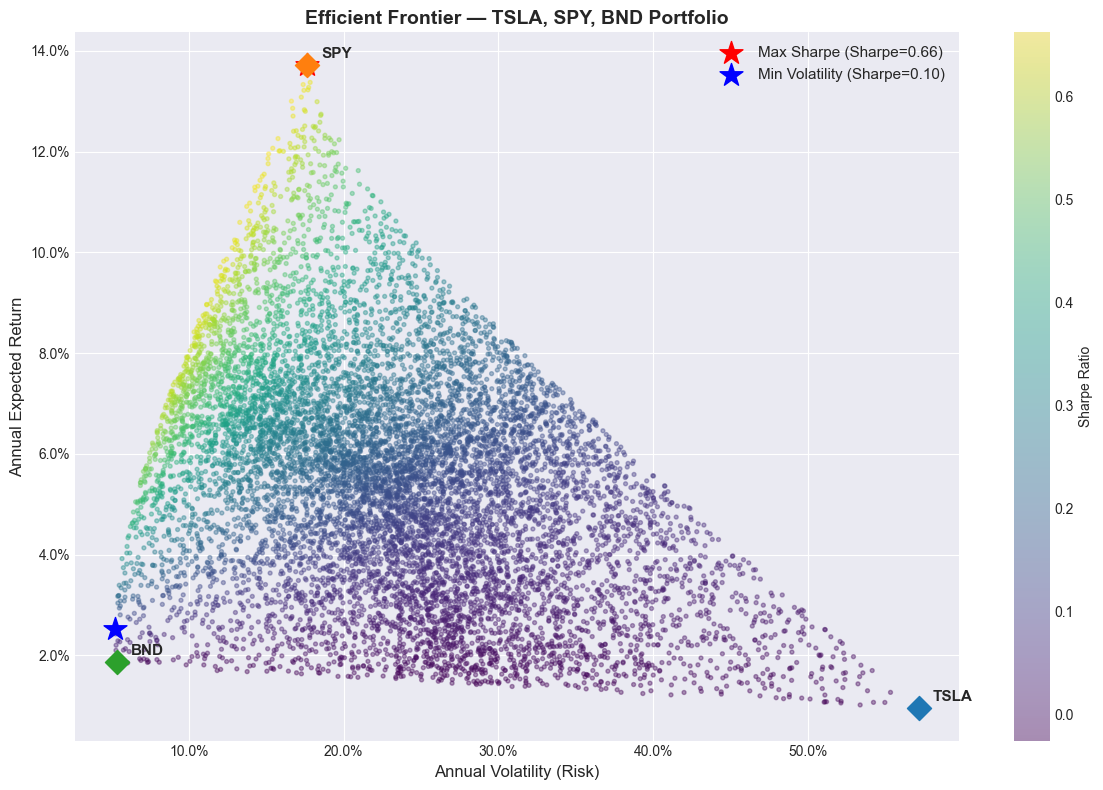

Efficient Frontier saved!


In [6]:

fig, ax = plt.subplots(figsize=(12, 8))

# Plot all random portfolios colored by Sharpe ratio
scatter = ax.scatter(
    results_df['Volatility'],
    results_df['Return'],
    c=results_df['Sharpe'],
    cmap='viridis',
    alpha=0.4,
    s=8
)
plt.colorbar(scatter, ax=ax, label='Sharpe Ratio')

# Max Sharpe Portfolio
ax.scatter(
    sharpe_perf[1], sharpe_perf[0],
    color='red', s=300, zorder=10,
    marker='*', label=f'Max Sharpe (Sharpe={sharpe_perf[2]:.2f})'
)

# Min Volatility Portfolio
ax.scatter(
    minvol_perf[1], minvol_perf[0],
    color='blue', s=300, zorder=10,
    marker='*', label=f'Min Volatility (Sharpe={minvol_perf[2]:.2f})'
)

# Annotate individual assets
for ticker in ['TSLA', 'SPY', 'BND']:
    asset_vol = np.sqrt(S.loc[ticker, ticker])
    asset_ret = mu[ticker]
    ax.scatter(asset_vol, asset_ret, s=150, zorder=10, marker='D')
    ax.annotate(ticker, (asset_vol, asset_ret),
                textcoords='offset points', xytext=(10, 5), fontsize=11,
                fontweight='bold')

ax.set_xlabel('Annual Volatility (Risk)', fontsize=12)
ax.set_ylabel('Annual Expected Return', fontsize=12)
ax.set_title('Efficient Frontier — TSLA, SPY, BND Portfolio',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1%}'))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1%}'))
plt.tight_layout()
plt.savefig('../data/processed/efficient_frontier.png', dpi=150, bbox_inches='tight')
plt.show()
print("Efficient Frontier saved!")

In [7]:

print("=" * 55)
print("FINAL PORTFOLIO RECOMMENDATION")
print("=" * 55)

# We recommend Max Sharpe portfolio for growth-oriented clients
recommended_weights = sharpe_weights
recommended_perf = sharpe_perf

print("\nRecommended Strategy: Maximum Sharpe Ratio Portfolio")
print("Rationale: Maximizes risk-adjusted return for GMF clients")
print("who seek growth while maintaining diversification.\n")

print("OPTIMAL PORTFOLIO WEIGHTS:")
print("-" * 35)
for ticker, weight in recommended_weights.items():
    role = {'TSLA': 'Growth Engine', 'SPY': 'Market Exposure', 'BND': 'Stability'}
    print(f"  {ticker}: {weight*100:.2f}%  [{role[ticker]}]")

print(f"\nPORTFOLIO METRICS:")
print("-" * 35)
print(f"  Expected Annual Return:  {recommended_perf[0]:.4%}")
print(f"  Expected Annual Volatility: {recommended_perf[1]:.4%}")
print(f"  Sharpe Ratio:            {recommended_perf[2]:.4f}")

print(f"\nCOMPARISON WITH INDIVIDUAL ASSETS:")
print("-" * 35)
print(f"  {'Asset':<8} {'Return':>10} {'Volatility':>12} {'Sharpe':>8}")
for ticker in ['TSLA', 'SPY', 'BND']:
    ret = mu[ticker]
    vol = np.sqrt(S.loc[ticker, ticker])
    sharpe = (ret - 0.02) / vol
    print(f"  {ticker:<8} {ret:>10.4%} {vol:>12.4%} {sharpe:>8.4f}")
print(f"  {'Portfolio':<8} {recommended_perf[0]:>10.4%} "
      f"{recommended_perf[1]:>12.4%} {recommended_perf[2]:>8.4f}")

# Save weights for Task 5
weights_df = pd.Series(recommended_weights)
weights_df.to_csv('../data/processed/optimal_weights.csv', header=False)
print("\nOptimal weights saved for Task 5 backtesting!")
print("\nTask 4 Complete!")

FINAL PORTFOLIO RECOMMENDATION

Recommended Strategy: Maximum Sharpe Ratio Portfolio
Rationale: Maximizes risk-adjusted return for GMF clients
who seek growth while maintaining diversification.

OPTIMAL PORTFOLIO WEIGHTS:
-----------------------------------
  BND: 0.00%  [Stability]
  SPY: 100.00%  [Market Exposure]
  TSLA: 0.00%  [Growth Engine]

PORTFOLIO METRICS:
-----------------------------------
  Expected Annual Return:  13.7310%
  Expected Annual Volatility: 17.6547%
  Sharpe Ratio:            0.6645

COMPARISON WITH INDIVIDUAL ASSETS:
-----------------------------------
  Asset        Return   Volatility   Sharpe
  TSLA        0.9511%     57.1775%  -0.0183
  SPY        13.7310%     17.6547%   0.6645
  BND         1.8715%      5.3135%  -0.0242
  Portfolio   13.7310%     17.6547%   0.6645

Optimal weights saved for Task 5 backtesting!

Task 4 Complete!


In [9]:
#Constrained Portfolio with minimum weights
print("=== CONSTRAINED PORTFOLIO (with min weights) ===\n")

# Force minimum allocations for diversification
ef_constrained = EfficientFrontier(mu, S)

# Set weight bounds - each asset must have at least 5%, max 60%
ef_constrained.add_constraint(lambda w: w[0] >= 0.05)  # BND min 5%
ef_constrained.add_constraint(lambda w: w[1] >= 0.10)  # SPY min 10%
ef_constrained.add_constraint(lambda w: w[2] >= 0.05)  # TSLA min 5%

ef_constrained.max_sharpe(risk_free_rate=0.02)
constrained_weights = ef_constrained.clean_weights()
constrained_perf = ef_constrained.portfolio_performance(
    verbose=True, risk_free_rate=0.02
)

print("\nConstrained Weights:")
for ticker, weight in constrained_weights.items():
    print(f"  {ticker}: {weight:.4f} ({weight*100:.2f}%)")

# Save constrained weights for Task 5
weights_series = pd.Series(constrained_weights)
weights_series.to_csv('../data/processed/optimal_weights.csv', header=False)

print("\n=== FINAL RECOMMENDATION ===")
print(f"Expected Annual Return:     {constrained_perf[0]:.4%}")
print(f"Expected Annual Volatility: {constrained_perf[1]:.4%}")
print(f"Sharpe Ratio:               {constrained_perf[2]:.4f}")
print("\nOptimal weights saved for Task 5!")
print("Task 4 Complete!")

=== CONSTRAINED PORTFOLIO (with min weights) ===

Expected annual return: 12.5%
Annual volatility: 17.5%
Sharpe Ratio: 0.60

Constrained Weights:
  BND: 0.0500 (5.00%)
  SPY: 0.9000 (90.00%)
  TSLA: 0.0500 (5.00%)

=== FINAL RECOMMENDATION ===
Expected Annual Return:     12.4990%
Expected Annual Volatility: 17.5104%
Sharpe Ratio:               0.5996

Optimal weights saved for Task 5!
Task 4 Complete!
